# PCA Sensitivity - Harmonization Trade-off

## Objective
Visualize the trade-off between **site-invariance** (privacy) and **pathology classification** (utility) across all harmonization methods and PCA variance levels.

Each point is one hospital. Axes show the delta relative to the raw baseline:
- **x (ΔSite MCC):** negative = harmonization *reduced* site discriminability → better privacy
- **y (ΔPath AUC):** positive = harmonization *improved* pathology AUC → better utility

The ideal outcome (top-left quadrant) means a method simultaneously reduces site effects and maintains or improves pathology performance.

## Key Insight
Without PCA, harmonized methods (especially ComBat) land in the **bottom-right** quadrant — worsening both privacy and utility (the paradox). With PCA, points shift toward top-left.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.visualization.style import apply_style
apply_style()
import seaborn as sns

RESULTS_PATH_SITE  = 'results/tables/05_pca_sensitivity/pca_sensitivity_results_site_catboost.csv'
RESULTS_PATH_PATHO = 'results/tables/05_pca_sensitivity/pca_sensitivity_results_patho_catboost.csv'
FIGURES_DIR        = 'results/figures/05_pca_sensitivity/tradeoff'

METHODS    = ['sitewise', 'combat', 'neurocombat', 'covbat']
PCA_ORDER  = ['None', '1.0', '0.99', '0.95', '0.90', '0.80']

## Build delta_df

In [3]:
# --- Site data (wide format: one column per hospital) ---
site_df = pd.read_csv(RESULTS_PATH_SITE)
# pca_var is a string column ('none','all','0.99',...); map to float for ordering
pca_str_to_float = {'none': 0.0, 'all': 1.0, '0.99': 0.99, '0.95': 0.95, '0.9': 0.90, '0.8': 0.80}
site_df['pca_var'] = site_df['pca_var'].astype(str).map(pca_str_to_float)

# Melt to long format (note: catboost CSVs use uppercase MCC_H1, MCC_H2, ...)
import re
site_cols = [c for c in site_df.columns if re.match(r'mcc_H\d+$', c, re.IGNORECASE)]
site_long = site_df.melt(
    id_vars=['method', 'pca_var', 'fold_id'],
    value_vars=site_cols,
    var_name='hospital',
    value_name='site_mcc',
)
site_long['hospital'] = site_long['hospital'].str.replace(r'^[Mm][Cc][Cc]_', '', regex=True)
site_mean = site_long.groupby(['method', 'pca_var', 'hospital'])['site_mcc'].mean().reset_index()

# --- Patho data (long format) ---
patho_df = pd.read_csv(RESULTS_PATH_PATHO)
patho_df['pca_var'] = patho_df['pca_var'].astype(str).map(pca_str_to_float)
patho_mean = (
    patho_df
    .groupby(['method', 'pca_var', 'hospital'])['auc']
    .mean()
    .reset_index()
    .rename(columns={'auc': 'patho_auc'})
)

# --- Merge and compute deltas vs raw ---
merged = site_mean.merge(patho_mean, on=['method', 'pca_var', 'hospital'])

raw_ref = (
    merged[merged['method'] == 'raw']
    [['pca_var', 'hospital', 'site_mcc', 'patho_auc']]
    .rename(columns={'site_mcc': 'raw_site_mcc', 'patho_auc': 'raw_patho_auc'})
)

delta_df = (
    merged[merged['method'].isin(METHODS)]
    .merge(raw_ref, on=['pca_var', 'hospital'])
)
delta_df['delta_mcc'] = delta_df['site_mcc'] - delta_df['raw_site_mcc']
delta_df['delta_auc'] = delta_df['patho_auc'] - delta_df['raw_patho_auc']

# Map pca_var floats to display labels
pca_label_map = {0.0: 'None', 1.0: '1.0', 0.99: '0.99', 0.95: '0.95', 0.90: '0.90', 0.80: '0.80'}
delta_df['pca_var'] = delta_df['pca_var'].map(pca_label_map)

print(delta_df.shape)
delta_df.head()

(720, 9)


,method,pca_var,hospital,site_mcc,patho_auc,raw_site_mcc,raw_patho_auc,delta_mcc,delta_auc
0,combat,None,H1,0.989014,0.830056,0.880835,0.801648,0.108178,0.028407
1,combat,None,H10,0.962609,0.821309,0.840371,0.806029,0.122238,0.015280
2,combat,None,H11,0.991740,0.851666,0.794938,0.853450,0.196803,-0.001784
3,combat,None,H12,0.984822,0.833691,0.797235,0.821913,0.187587,0.011778
4,combat,None,H13,0.953649,0.832439,0.807434,0.815923,0.146214,0.016516


## Trade-off grid: rows = method, cols = PCA variance

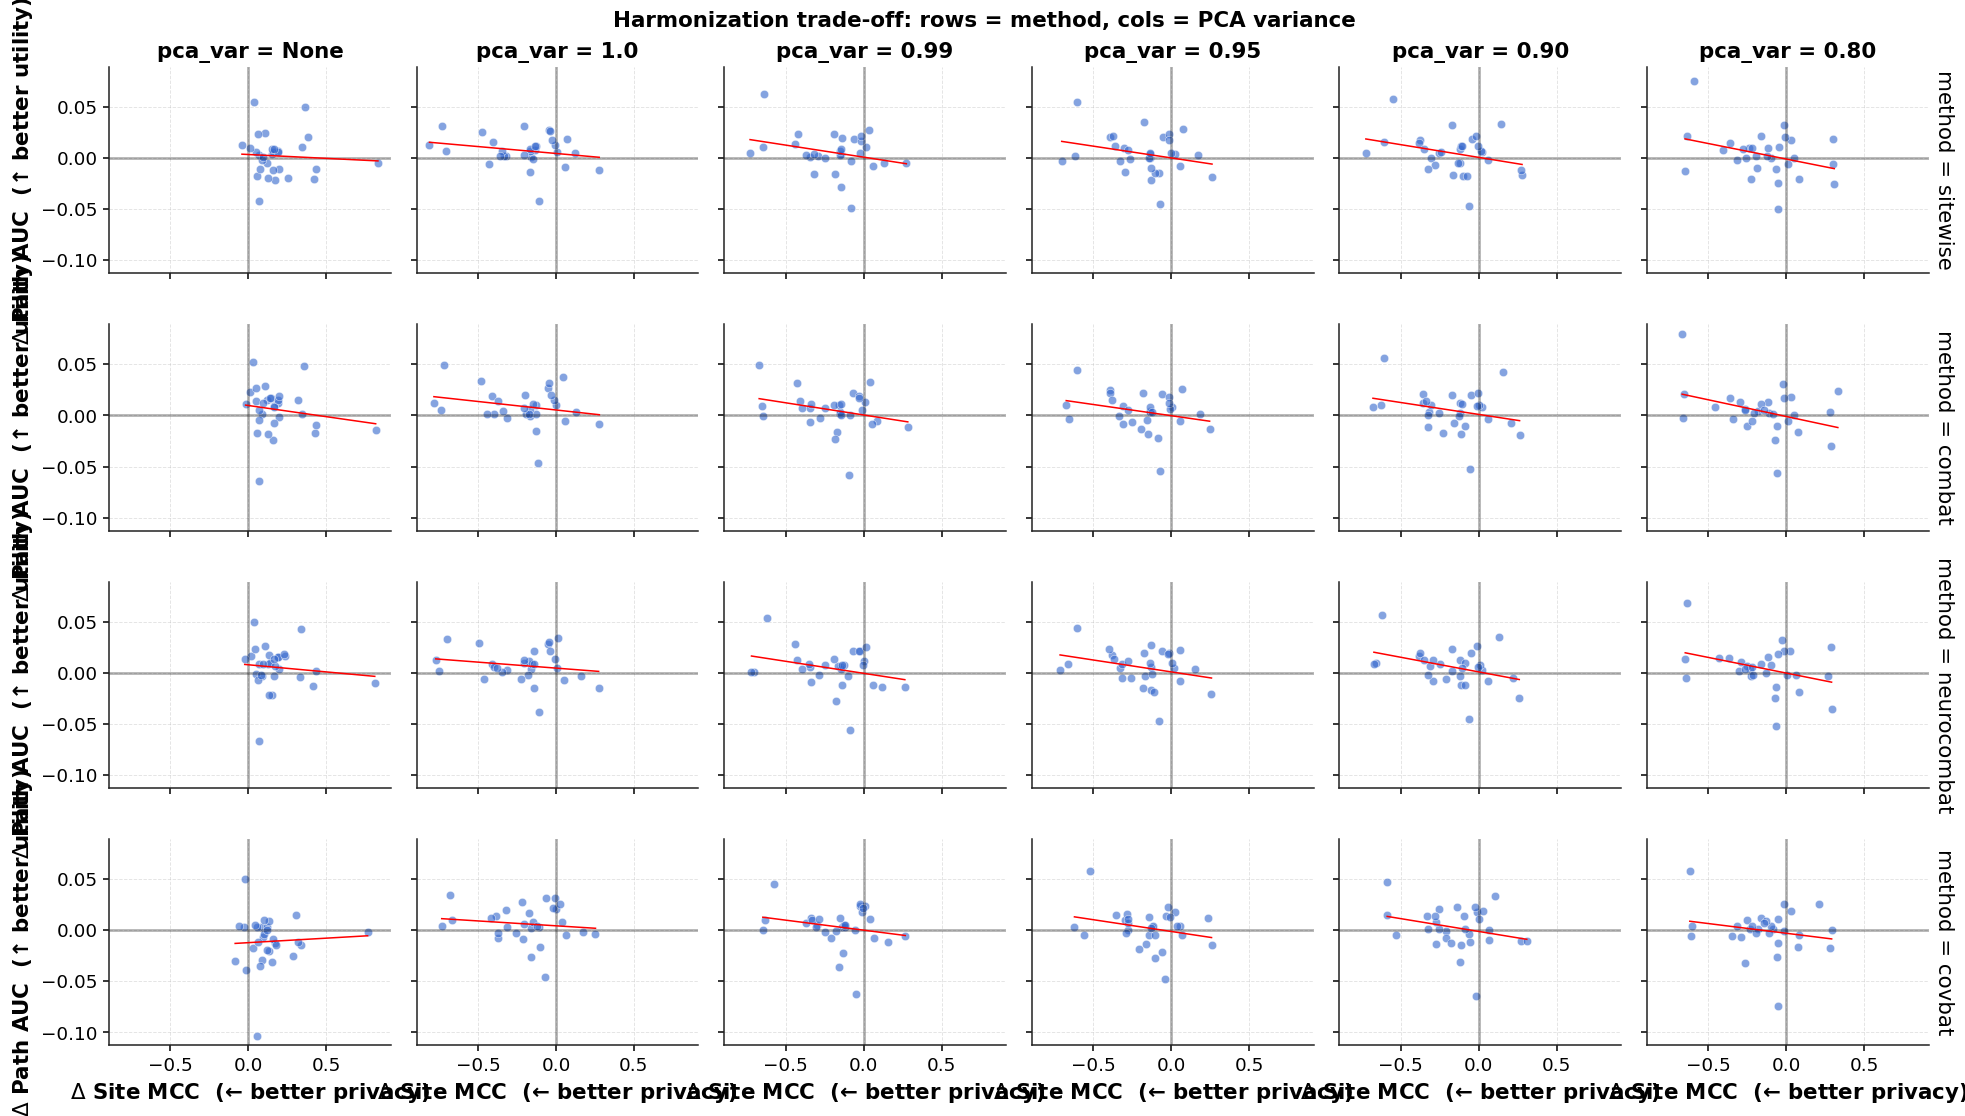

In [4]:

g = sns.FacetGrid(
    delta_df,
    row='method',
    col='pca_var',
    row_order=METHODS,
    col_order=PCA_ORDER,
    margin_titles=True,
    height=2.5,
    aspect=1.2,
    sharex=True,
    sharey=True,
)

g.map(sns.scatterplot, 'delta_mcc', 'delta_auc', alpha=0.6, s=30, color='#3366cc')
g.map(plt.axvline, x=0, color='black', linestyle='-', alpha=0.3)
g.map(plt.axhline, y=0, color='black', linestyle='-', alpha=0.3)
g.map(sns.regplot, 'delta_mcc', 'delta_auc',
      scatter=False, color='red', ci=None, line_kws={'linewidth': 1})

g.set_axis_labels(
    r'$\Delta$ Site MCC  (← better privacy)',
    r'$\Delta$ Path AUC  (↑ better utility)'
)
g.fig.suptitle(
    'Harmonization trade-off: rows = method, cols = PCA variance',
    fontsize=14, y=1.01
)

os.makedirs(FIGURES_DIR, exist_ok=True)
g.fig.savefig(f'{FIGURES_DIR}/tradeoff_grid.png', dpi=150, bbox_inches='tight')
plt.show()